In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN

In [45]:
df = pd.read_csv(
    "cleaned_supply_chain_data.csv"
)

In [46]:
df.head()

,store_id,city,latitude,longitude,population,store_type,monthly_demand,demand_variability,priority_level,region,delivery_sla_hours,transport_cost_factor
0,S1,Delhi,28.6600,77.2300,29617000.0,Hypermarket,56261,Medium,High,North,24,3.031767
1,S2,Mumbai,18.9667,72.8333,23355000.0,Hypermarket,55131,Medium,High,West/East,24,4.639936
2,S3,Kolkta,22.5411,88.3378,17560000.0,Hypermarket,38379,Medium,High,Central,24,5.268889
3,S4,Bangalore,12.9699,77.5980,13707000.0,Hypermarket,28495,Medium,High,South,24,4.220803
4,S5,Chennai,13.0825,80.2750,11324000.0,Hypermarket,19531,Medium,High,South,24,4.118602


In [47]:
coords = df[['latitude', 'longitude']]

In [48]:
eps = 3
min_samples = 3

In [49]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=3
)

df['cluster'] = dbscan.fit_predict(coords)
df['cluster'].value_counts()

cluster
-1    29
 0    18
 1    11
 3    10
 2     8
 4     5
 5     4
 7     4
 6     3
Name: count, dtype: int64

In [50]:
df[['city','cluster']].head(20)

,city,cluster
0,Delhi,0
1,Mumbai,1
2,Kolkta,2
3,Bangalore,3
4,Chennai,-1
5,Hyderbd,-1
6,Pune,1
7,Ahmadbd,4
8,Srat,4
9,Lucknow,-1


In [51]:
df[['city','cluster']].head(20)


,city,cluster
0,Delhi,0
1,Mumbai,1
2,Kolkta,2
3,Bangalore,3
4,Chennai,-1
5,Hyderbd,-1
6,Pune,1
7,Ahmadbd,4
8,Srat,4
9,Lucknow,-1


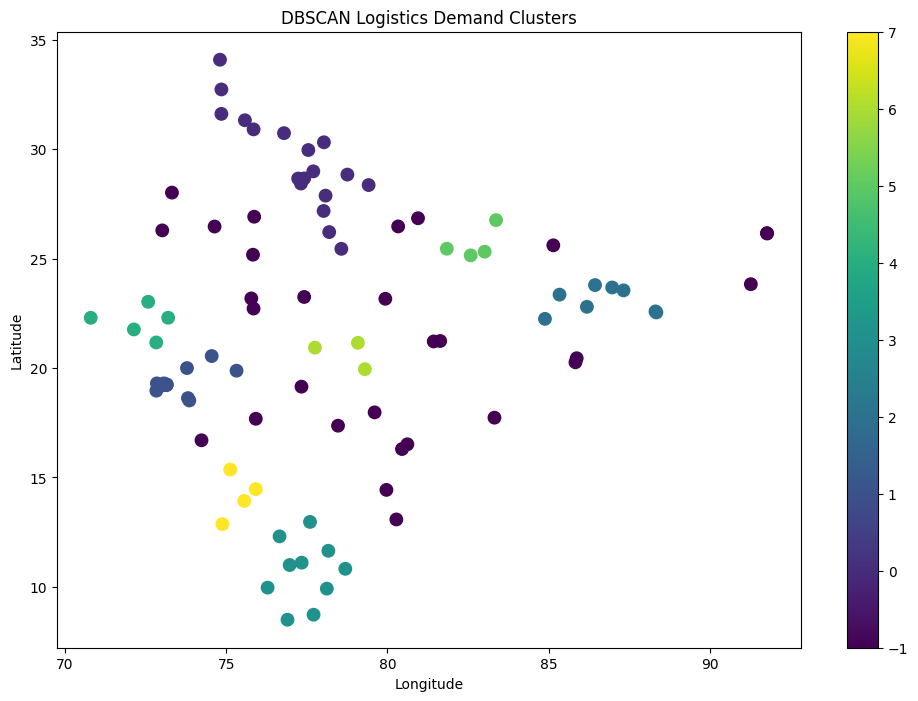

In [52]:
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    df['longitude'],
    df['latitude'],
    c=df['cluster'],
    s=80
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "DBSCAN Logistics Demand Clusters"
)

plt.colorbar(scatter)

plt.show()

In [53]:
cluster_demand = (
    df.groupby('cluster')
    ['monthly_demand']
    .sum()
)

print(cluster_demand)

cluster
-1    102316
 0     91567
 1     87505
 2     52065
 3     44763
 4     36338
 5     12316
 6      6728
 7      5307
Name: monthly_demand, dtype: int64


In [54]:
df.to_csv(
    "dbscan_clustered_data.csv",
    index=False
)

In [55]:
from sklearn.cluster import KMeans

In [56]:
clustered_df = df[
    df['cluster'] != -1
]
print(clustered_df.head())

  store_id       city  latitude  longitude  population    store_type  \
0       S1      Delhi   28.6600    77.2300  29617000.0   Hypermarket   
1       S2     Mumbai   18.9667    72.8333  23355000.0   Hypermarket   
2       S3     Kolkta   22.5411    88.3378  17560000.0   Hypermarket   
3       S4  Bangalore   12.9699    77.5980  13707000.0   Hypermarket   
6       S7       Pune   18.5196    73.8553   7764000.0  Regional Hub   

   monthly_demand demand_variability priority_level     region  \
0           56261             Medium           High      North   
1           55131             Medium           High  West/East   
2           38379             Medium           High    Central   
3           28495             Medium           High      South   
6           12783                Low         Medium  West/East   

   delivery_sla_hours  transport_cost_factor  cluster  
0                  24               3.031767        0  
1                  24               4.639936        1  
2 

In [57]:
num_warehouses = 6

In [58]:
warehouse_coords = clustered_df[
    ['latitude', 'longitude']
]

In [59]:
kmeans = KMeans(
    n_clusters=num_warehouses,
    random_state=42
)

clustered_df['warehouse_cluster'] = (
    kmeans.fit_predict(warehouse_coords)
)

In [60]:
warehouse_locations = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=['latitude', 'longitude']
)

warehouse_locations

,latitude,longitude
0,23.937250,85.380817
1,20.209556,73.180656
2,28.246783,78.022742
3,11.686114,76.850707
4,31.901717,75.454167
5,20.679067,78.711033


In [61]:
warehouse_locations['warehouse_id'] = [
    f"WH{i+1}"
    for i in range(len(warehouse_locations))
]

In [62]:
warehouse_locations

,latitude,longitude,warehouse_id
0,23.937250,85.380817,WH1
1,20.209556,73.180656,WH2
2,28.246783,78.022742,WH3
3,11.686114,76.850707,WH4
4,31.901717,75.454167,WH5
5,20.679067,78.711033,WH6


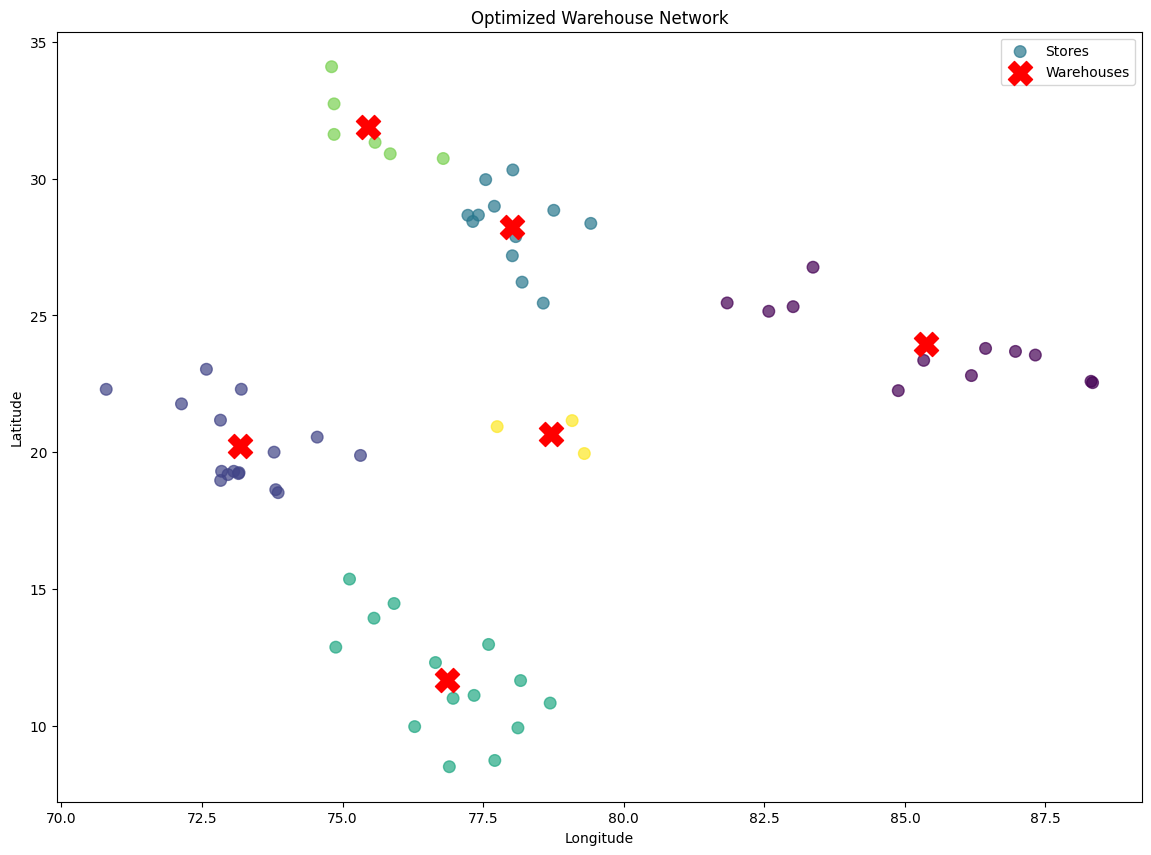

In [63]:
plt.figure(figsize=(14,10))

# STORES
plt.scatter(
    clustered_df['longitude'],
    clustered_df['latitude'],
    c=clustered_df['warehouse_cluster'],
    s=70,
    alpha=0.7,
    label='Stores'
)

# WAREHOUSES
plt.scatter(
    warehouse_locations['longitude'],
    warehouse_locations['latitude'],
    c='red',
    marker='X',
    s=300,
    label='Warehouses'
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Optimized Warehouse Network"
)

plt.legend()

plt.show()

In [64]:
warehouse_locations = warehouse_locations[
    [
        'warehouse_id',
        'latitude',
        'longitude'
    ]
]

In [65]:
from haversine import haversine

In [66]:
distance_data = []
for _, store in clustered_df.iterrows():

    for _, warehouse in warehouse_locations.iterrows():

        store_coords = (
            store['latitude'],
            store['longitude']
        )

        warehouse_coords = (
            warehouse['latitude'],
            warehouse['longitude']
        )

        distance = haversine(
            store_coords,
            warehouse_coords
        )

        distance_data.append({

            'store_id': store['store_id'],

            'city': store['city'],

            'warehouse_id':
            warehouse['warehouse_id'],

            'distance_km':
            round(distance, 2),

            'monthly_demand':
            store['monthly_demand'],

            'transport_cost_factor':
            store['transport_cost_factor']

        })

In [67]:
distance_df = pd.DataFrame(distance_data)


In [68]:
distance_df.head()
print(distance_df.columns)

Index(['store_id', 'city', 'warehouse_id', 'distance_km', 'monthly_demand',
       'transport_cost_factor'],
      dtype='str')


In [69]:
distance_df['transport_cost'] = (
    distance_df['distance_km']
    *
    distance_df['monthly_demand']
    *
    distance_df['transport_cost_factor']
)

In [70]:
distance_df.head()

,store_id,city,warehouse_id,distance_km,monthly_demand,transport_cost_factor,transport_cost
0,S1,Delhi,WH1,967.01,56261,3.031767,1.649431e+08
1,S1,Delhi,WH2,1024.93,56261,3.031767,1.748225e+08
2,S1,Delhi,WH3,90.10,56261,3.031767,1.536838e+07
3,S1,Delhi,WH4,1887.82,56261,3.031767,3.220059e+08
4,S1,Delhi,WH5,398.74,56261,3.031767,6.801317e+07


In [71]:
best_allocations = distance_df.loc[

    distance_df.groupby('store_id')
    ['transport_cost']
    .idxmin()

]

In [72]:
best_allocations = distance_df.loc[

    distance_df.groupby('store_id')
    ['transport_cost']
    .idxmin()

]

In [73]:
best_allocations.head()

,store_id,city,warehouse_id,distance_km,monthly_demand,transport_cost_factor,transport_cost
2,S1,Delhi,WH3,90.10,56261,3.031767,1.536838e+07
42,S13,Mirzpur,WH1,313.74,5658,4.903823,8.704976e+06
53,S14,Ngpur,WH6,65.43,4257,5.588441,1.556579e+06
56,S15,Ghzibd,WH3,75.43,4156,5.548346,1.739335e+06
61,S17,Vadodara,WH2,232.46,3808,4.568127,4.043741e+06


In [74]:
best_allocations['delivery_time_hours'] = (

    best_allocations['distance_km']

    / 45

)

In [75]:
best_allocations = best_allocations.merge(

    clustered_df[
        [
            'store_id',
            'delivery_sla_hours'
        ]
    ],

    on='store_id',
    how='left'
)

In [76]:
best_allocations['sla_status'] = np.where(

    best_allocations[
        'delivery_time_hours'
    ]

    <=

    best_allocations[
        'delivery_sla_hours'
    ],

    'Within SLA',

    'SLA Violated'
)

In [77]:
best_allocations[
    [
        'city',
        'warehouse_id',
        'distance_km',
        'delivery_time_hours',
        'delivery_sla_hours',
        'sla_status'
    ]
].head()

,city,warehouse_id,distance_km,delivery_time_hours,delivery_sla_hours,sla_status
0,Delhi,WH3,90.10,2.002222,24,Within SLA
1,Mirzpur,WH1,313.74,6.972000,48,Within SLA
2,Ngpur,WH6,65.43,1.454000,48,Within SLA
3,Ghzibd,WH3,75.43,1.676222,48,Within SLA
4,Vadodara,WH2,232.46,5.165778,48,Within SLA


In [78]:
warehouse_load = (

    best_allocations.groupby(
        'warehouse_id'
    )

    ['monthly_demand']

    .sum()

    .reset_index()
)

In [79]:
warehouse_load

,warehouse_id,monthly_demand
0,WH1,64381
1,WH2,123843
2,WH3,79859
3,WH4,50070
4,WH5,11708
5,WH6,6728


In [80]:
warehouse_load['warehouse_capacity'] = 1200000

In [81]:
warehouse_load['utilization_percent'] = (

    warehouse_load['monthly_demand']

    /

    warehouse_load['warehouse_capacity']

) * 100

In [82]:
def warehouse_status(utilization):

    if utilization > 90:
        return "Overcrowded"

    elif utilization >= 60:
        return "Balanced"

    else:
        return "Underutilized"

In [83]:
warehouse_load['warehouse_status'] = (

    warehouse_load['utilization_percent']

    .apply(warehouse_status)
)

In [84]:
warehouse_load

,warehouse_id,monthly_demand,warehouse_capacity,utilization_percent,warehouse_status
0,WH1,64381,1200000,5.365083,Underutilized
1,WH2,123843,1200000,10.320250,Underutilized
2,WH3,79859,1200000,6.654917,Underutilized
3,WH4,50070,1200000,4.172500,Underutilized
4,WH5,11708,1200000,0.975667,Underutilized
5,WH6,6728,1200000,0.560667,Underutilized


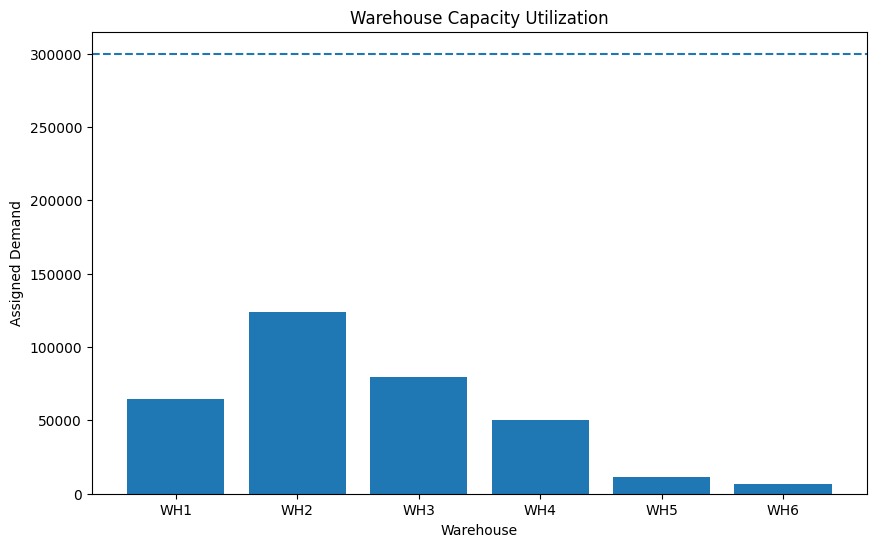

In [85]:
plt.figure(figsize=(10,6))

plt.bar(
    warehouse_load['warehouse_id'],
    warehouse_load['monthly_demand']
)

plt.axhline(
    y=300000,
    linestyle='--'
)

plt.title(
    "Warehouse Capacity Utilization"
)

plt.xlabel("Warehouse")

plt.ylabel("Assigned Demand")

plt.show()

In [86]:
warehouse_load.sort_values(
    by='utilization_percent',
    ascending=False
)

,warehouse_id,monthly_demand,warehouse_capacity,utilization_percent,warehouse_status
1,WH2,123843,1200000,10.320250,Underutilized
2,WH3,79859,1200000,6.654917,Underutilized
0,WH1,64381,1200000,5.365083,Underutilized
3,WH4,50070,1200000,4.172500,Underutilized
4,WH5,11708,1200000,0.975667,Underutilized
5,WH6,6728,1200000,0.560667,Underutilized
